In [1]:
from maskseg_build_everything import (
    build_maskvar_flex,
    build_maskvar_flex_5_stages,
    build_maskvar_flex_mobile_5_stages,
    build_var_image_encoder,
    build_prompt_encoder,
    build_sam_image_encoder
)
import torch
import torch.nn.functional as F

/home/clc/miniconda3/envs/var_v2/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/clc/miniconda3/envs/var_v2/lib/python3.11/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/home/clc/miniconda3/envs/var_v2/lib/python3.11/site-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/data/clc/maskseg/models/tinyvit.py:656: UserWarning: Overwriting tiny_vit_5m_224 in registry with models.tinyvit.tiny_vit_5m_224. This is becaus

In [2]:
device = 'cuda:3'

In [3]:
from models.prompt_encoder import PromptEncoder

# vqvae = build_vqvae_single(vqvae_checkpoint_path='ckpt/vqvae_single.pth').to(device)
# sam_image_encoder = build_mobile_sam_image_encoder().to(device)
var_image_encoder = build_var_image_encoder().to(device)
prompt_encoder: PromptEncoder = build_prompt_encoder().to(device)
vqvae, maskvar, sam_image_encoder = build_maskvar_flex_mobile_5_stages('out_vqvae_5_stages_v1/ckpt/vqvae_single_epoch_50.pth', 'ckpt/mobile_sam.pt', device=device)
# vqvae, maskvar, sam_image_encoder = build_maskvar_flex('out_vqvae_4_stages_v2/ckpt/vqvae_single_epoch_50.pth', 'ckpt/sam_vit_b_01ec64.pth', device=device)
maskvar.init_block_mask()

# vqvae = torch.compile(vqvae)
# maskvar = torch.compile(maskvar)
# sam_image_encoder = torch.compile(sam_image_encoder)
# prompt_encoder = torch.compile(prompt_encoder)

image = torch.randn(1, 3, 256, 256).to(device)
image_interpolated = F.interpolate(image, size=(1024, 1024), mode='bilinear', align_corners=False)
sam_image_embedding = sam_image_encoder(image_interpolated)
pe_grids = [prompt_encoder.pe_layer.forward((pn, pn)).permute(1, 2, 0) for pn in maskvar.patch_nums]

prompt_points_coords = [[[128, 128]]]
prompt_points_labels = [[1]]

prompt_points_coords = torch.Tensor(prompt_points_coords).to(device)
prompt_points_labels = torch.Tensor(prompt_points_labels).to(device)

label_B = torch.zeros(1, dtype=torch.long).to(device)

gt_mask = torch.randn(1, 1, 256, 256).to(device)
gt_mask_ids= vqvae.img_to_idxBl(gt_mask)
x_BLCv_wo_first_l = vqvae.quantize.idxBl_to_var_input(gt_mask_ids)



[constructor]  ==== (fusing_add_ln=0/4, fusing_mlp=0/4) ==== 
    [VAR config ] embed_dim=256, num_heads=4, depth=4, mlp_ratio=2
    [drop ratios ] drop_rate=0.1, drop_path_rate=0.1 (tensor([0.0000, 0.0333, 0.0667, 0.1000]))



In [4]:
x_BLCv_wo_first_l.shape

torch.Size([1, 1920, 32])

In [5]:
logits = maskvar.forward(label_B=label_B, x_BLCv_wo_first_l=x_BLCv_wo_first_l, sam_image_embedding=sam_image_embedding, points_coords=prompt_points_coords, points_labels=prompt_points_labels)

In [6]:
from models.helpers import sample_with_top_k_top_p_
import torchvision
from PIL import Image
import numpy as np

In [7]:
idx = sample_with_top_k_top_p_(logits, top_k=1, num_samples=1)[:, :, 0]

In [8]:
# v_patch_nums=(1, 2, 4, 8, 12, 16, 20, 24, 28, 32)
v_patch_nums = (1, 8, 16, 24, 32)

indices = []
sum = 0
for i, pn in enumerate(v_patch_nums):
    indices.append(idx[:, sum:sum+pn*pn].to(device))
    sum += pn*pn


In [9]:
for ind in indices:
    print(ind.shape, ind.device)

torch.Size([1, 1]) cuda:3
torch.Size([1, 64]) cuda:3
torch.Size([1, 256]) cuda:3
torch.Size([1, 576]) cuda:3
torch.Size([1, 1024]) cuda:3


5 torch.Size([1, 1024])


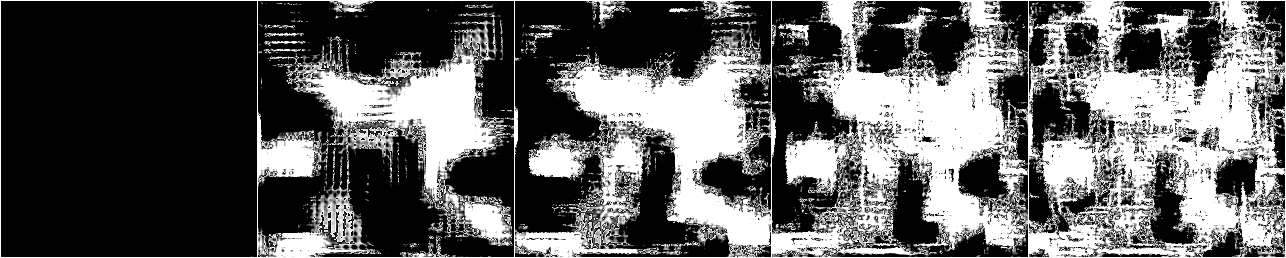

In [10]:
result = vqvae.idxBl_to_img(indices, same_shape=True)
print(len(indices), indices[-1].shape)
# result_conv = [edge(item) for item in result]
# result = [(mask > 0).float() for mask in result]
chw = torchvision.utils.make_grid(torch.cat(result[:], dim=0), nrow=5, 
padding=1, pad_value=1.0)

chw = chw.permute(1, 2, 0).mul_(255).cpu().numpy()
chw = Image.fromarray(chw.astype(np.uint8))
chw

In [11]:
image = maskvar.autoregressive_infer_cfg(B=1, label_B=None, sam_image_embedding=sam_image_embedding, points_coords=prompt_points_coords, points_labels=prompt_points_labels)

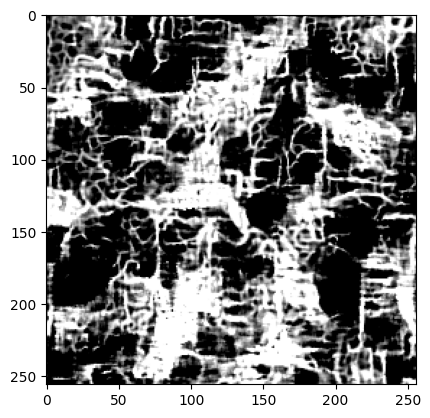

In [12]:
import matplotlib.pyplot as plt

plt.imshow(image[0].permute(1, 2, 0).cpu().numpy(), cmap='gray')